In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import math
import pandas as pd
import glob
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from datetime import datetime
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from dateutil.relativedelta import relativedelta
import xgboost as xgb


In [ ]:
start_train_date = "2025-01-01T00:00:00.000000"


datasetPath = datasetPath = "/content/drive/MyDrive/Colab Notebooks/nyc-taxi-drift-forecasting/data/aggregatedData.csv"
Catcolumns = ['day_factor', 'PULocationID']
df = pl.read_csv(datasetPath)
df = df.with_columns(
    pl.col("tpep_pickup_datetime").str.to_datetime("%Y-%m-%dT%H:%M:%S%.f")
)
df = df.sort("tpep_pickup_datetime")
df.head()



tpep_pickup_datetime,PULocationID,trip_count,hour,day_of_month,year,month,is_weekend,day_factor
datetime[μs],i64,i64,i64,i64,i64,i64,bool,str
2025-01-01 00:00:00,22,3,0,1,2025,1,false,"""Wednesday"""
2025-01-01 00:00:00,40,4,0,1,2025,1,false,"""Wednesday"""
2025-01-01 00:00:00,14,4,0,1,2025,1,false,"""Wednesday"""
2025-01-01 00:00:00,218,3,0,1,2025,1,false,"""Wednesday"""
2025-01-01 00:00:00,129,4,0,1,2025,1,false,"""Wednesday"""


In [ ]:
#Hour x Location Interaction Feature

df = df.with_columns(
    (pl.col('PULocationID').cast(str) + '_' + pl.col('hour').cast(str)).alias('loc_hour_key')
)

df = df.sort(['PULocationID', 'tpep_pickup_datetime'])

# 3. Create the 1-hour and 2-hour lag features using window functions globally
df = df.with_columns([
    pl.col('trip_count').shift(1).over('PULocationID').alias('trip_count_lag_1h'),
    pl.col('trip_count').shift(2).over('PULocationID').alias('trip_count_lag_2h')
])


In [ ]:
df.head()

tpep_pickup_datetime,PULocationID,trip_count,hour,day_of_month,year,month,is_weekend,day_factor,loc_hour_key,trip_count_lag_1h,trip_count_lag_2h
datetime[μs],i64,i64,i64,i64,i64,i64,bool,str,str,i64,i64
2025-01-01 06:00:00,1,1,6,1,2025,1,false,"""Wednesday""","""1_6""",null,null
2025-01-01 09:00:00,1,4,9,1,2025,1,false,"""Wednesday""","""1_9""",1,null
2025-01-01 12:00:00,1,2,12,1,2025,1,false,"""Wednesday""","""1_12""",4,1
2025-01-01 13:00:00,1,4,13,1,2025,1,false,"""Wednesday""","""1_13""",2,4
2025-01-01 14:00:00,1,2,14,1,2025,1,false,"""Wednesday""","""1_14""",4,2


In [ ]:
start_train_date = datetime(2025, 1, 1)
end_train_date = datetime(2025, 12, 31)

window_size = 4
forecast_size = 1

results = []
metrics_summary = []
current_train_start = start_train_date


while True:
  current_train_end = current_train_start + relativedelta(months=window_size)
  current_test_end = current_train_end + relativedelta(months=forecast_size)

  if current_test_end > end_train_date:
    break



  train_df = df.filter(
      (pl.col("tpep_pickup_datetime") >= current_train_start) &
      (pl.col("tpep_pickup_datetime") < current_train_end)
  )

  test_df = df.filter(
      (pl.col("tpep_pickup_datetime") >= current_train_end) &
      (pl.col("tpep_pickup_datetime") < current_test_end)
  )



  loc_hour_avg = (
    train_df.group_by('loc_hour_key')
    .agg(pl.col('trip_count').mean().alias('loc_hour_avg'))
  )
  global_avg = train_df['trip_count'].mean()


  train_df = train_df.join(loc_hour_avg, on='loc_hour_key', how='left')
  test_df = test_df.join(loc_hour_avg, on='loc_hour_key', how='left')
  test_df = test_df.with_columns(pl.col('loc_hour_avg').fill_null(global_avg))

  train_df = train_df.with_columns([
    pl.col('trip_count_lag_1h').fill_null(pl.col('loc_hour_avg')),
    pl.col('trip_count_lag_2h').fill_null(pl.col('loc_hour_avg'))
  ])

  test_df = test_df.with_columns([
    pl.col('trip_count_lag_1h').fill_null(pl.col('loc_hour_avg')),
    pl.col('trip_count_lag_2h').fill_null(pl.col('loc_hour_avg'))
  ])


  train_df = train_df.drop(['loc_hour_key'])
  test_df = test_df.drop(['loc_hour_key'])



  # Step 2: recombine to one-hot encode consistently, then re-split
  combined = pl.concat([train_df.with_columns(pl.lit('train').alias('_split')),
                       test_df.with_columns(pl.lit('test').alias('_split'))])


  combined = combined.to_dummies(Catcolumns, drop_first=True)

  combined = combined.with_columns([
    (2 * np.pi * pl.col('hour') / 24).sin().alias('hour_sin'),
    (2 * np.pi * pl.col('hour') / 24).cos().alias('hour_cos')
  ])

  test_timestamps = test_df['tpep_pickup_datetime'].to_numpy()


  combined = combined.drop('tpep_pickup_datetime')
  train_df = combined.filter(pl.col('_split') == 'train').drop('_split')
  test_df = combined.filter(pl.col('_split') == 'test').drop('_split')


  train_df = train_df.to_pandas()
  test_df = test_df.to_pandas()

  X_train, y_train = train_df.drop(columns = 'trip_count'), train_df['trip_count']
  X_test, y_test = test_df.drop(columns = 'trip_count'), test_df['trip_count']


  X_train = X_train.drop(columns=['hour'])
  X_test = X_test.drop(columns=['hour'])





  #Using and Testing on Chosen Model of XGBoost


  xgModel = xgb.XGBRegressor(
    tree_method = 'hist',
    enable_categorical = True,
    n_estimators=200,     # Maximum number of sequential trees
    max_depth=6,          # Depth of each tree
    learning_rate=0.02,    # Step size shrinkage (eta)

  )

  xgModel.fit(X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100)

  y_predX = xgModel.predict(X_test)

  res = np.abs(y_predX - y_test)
  mse = mean_squared_error(y_true = y_test, y_pred = y_predX)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_test, y_predX)
  r2 = r2_score(y_test, y_predX)
  print(f"RMSE: {rmse:.4f}")
  print(f"R² Score: {r2:.4f}")
  print(f"Mean Absolute Residual (Matches MAE): {res.mean():.4f}")
  print(f"Max Absolute Residual Error: {res.max():.4f}")


  window_predictions_df = pl.DataFrame({
      "timestamp": test_timestamps,
      "test_month": current_train_end.strftime("%Y-%m"),
      "actuals": y_test.to_numpy(),
      "predictions": y_predX.astype(np.float64)
  })

  results.append(window_predictions_df)

  metrics_summary.append({
      "test_month": current_train_end.strftime("%Y-%m"),
      "rmse": rmse,
      "mae": mae,
      "r2": r2,
      "max_residual": res.max(),
      "mean_residual": res.mean()
  })

  current_train_start = current_train_start + relativedelta(months=1)


forecast_df = pl.concat(results)
forecast_df = forecast_df.with_columns(
    (pl.col("actuals") - pl.col("predictions")).alias("residual")
)

summary_df = pl.DataFrame(metrics_summary)
print("--- RAW PREDICTIONS FRAME (thousands of rows) ---")
print(forecast_df.head())

print(summary_df)

[0]	validation_0-rmse:75.46053
[100]	validation_0-rmse:20.41724
[199]	validation_0-rmse:15.87421
RMSE: 15.8742
R² Score: 0.9573
Mean Absolute Residual (Matches MAE): 6.5914
Max Absolute Residual Error: 403.2253
[0]	validation_0-rmse:72.09410
[100]	validation_0-rmse:17.87175
[199]	validation_0-rmse:14.08181
RMSE: 14.0818
R² Score: 0.9633
Mean Absolute Residual (Matches MAE): 6.1145
Max Absolute Residual Error: 322.3639
[0]	validation_0-rmse:64.51626
[100]	validation_0-rmse:15.38539
[199]	validation_0-rmse:13.71196
RMSE: 13.7120
R² Score: 0.9564
Mean Absolute Residual (Matches MAE): 5.9355
Max Absolute Residual Error: 348.8253
[0]	validation_0-rmse:58.70451
[100]	validation_0-rmse:14.20785
[199]	validation_0-rmse:12.79821
RMSE: 12.7982
R² Score: 0.9540
Mean Absolute Residual (Matches MAE): 5.5552
Max Absolute Residual Error: 288.5889
[0]	validation_0-rmse:74.06381
[100]	validation_0-rmse:20.03477
[199]	validation_0-rmse:16.49611
RMSE: 16.4961
R² Score: 0.9521
Mean Absolute Residual (Matc

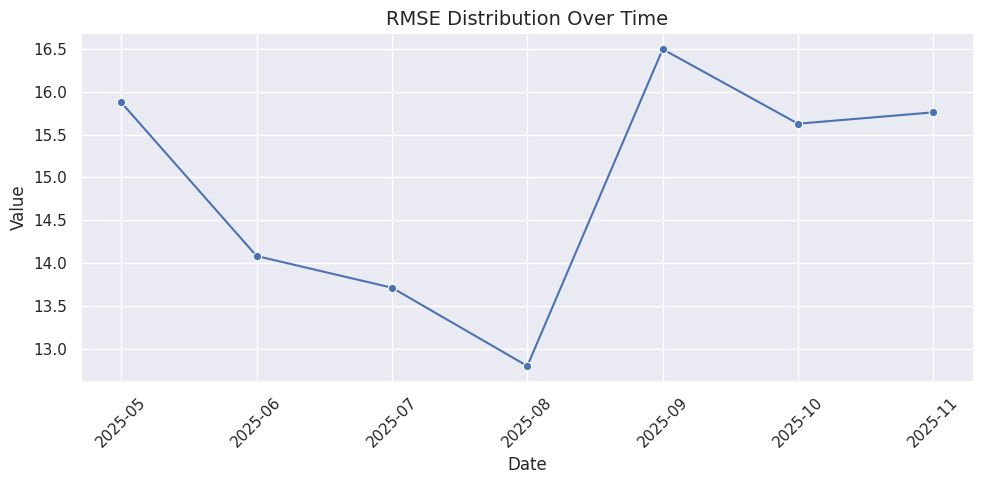

In [ ]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="darkgrid")

# 3. Draw the line plot
sns.lineplot(data=summary_df.to_pandas(), x="test_month", y="rmse", marker="o")

# 4. Clean up labels
plt.title("RMSE Distribution Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

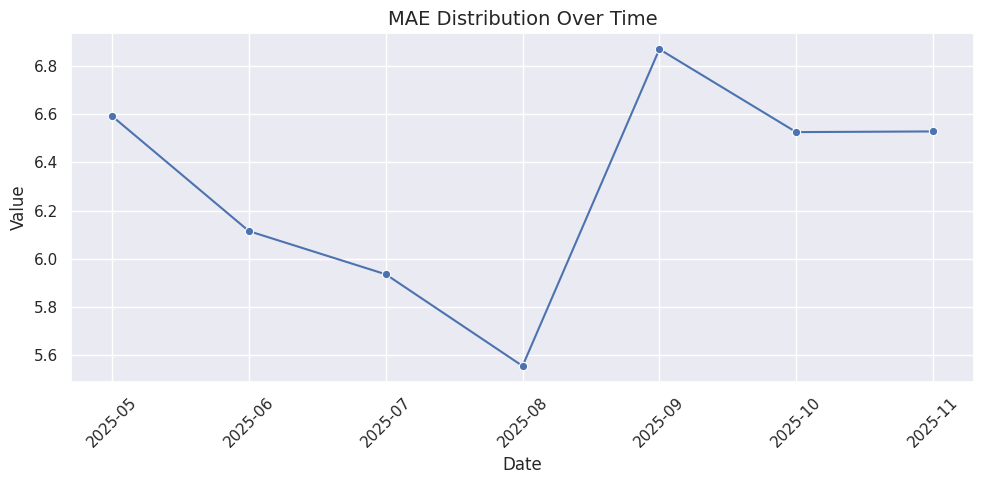

In [ ]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="darkgrid")

# 3. Draw the line plot
sns.lineplot(data=summary_df.to_pandas(), x="test_month", y="mae", marker="o")

# 4. Clean up labels
plt.title("MAE Distribution Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

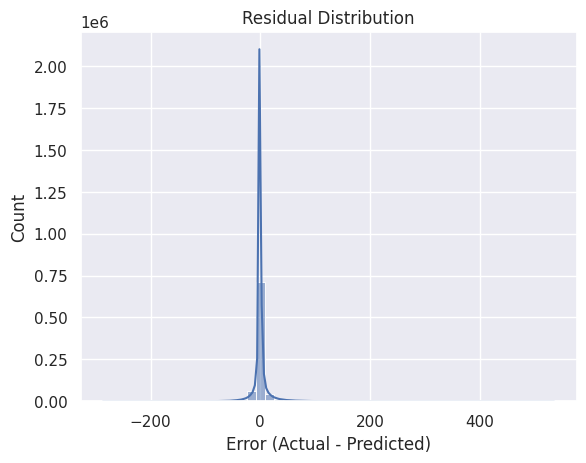

In [ ]:
sns.histplot(data=forecast_df.to_pandas(), x="residual", kde=True, bins=50)
plt.title("Residual Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.show()

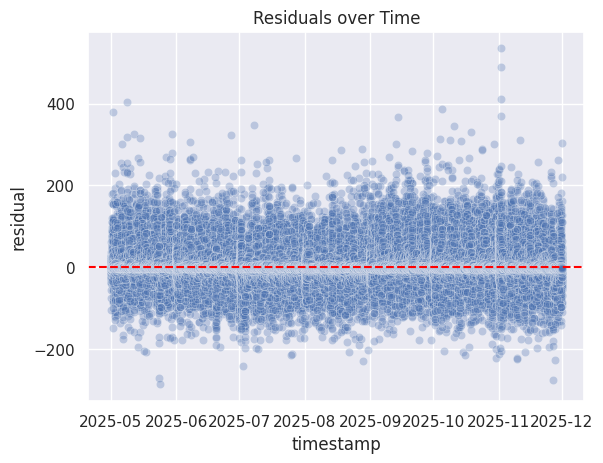

In [ ]:
sns.scatterplot(data=forecast_df.to_pandas(), x="timestamp", y="residual", alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals over Time")
plt.show()

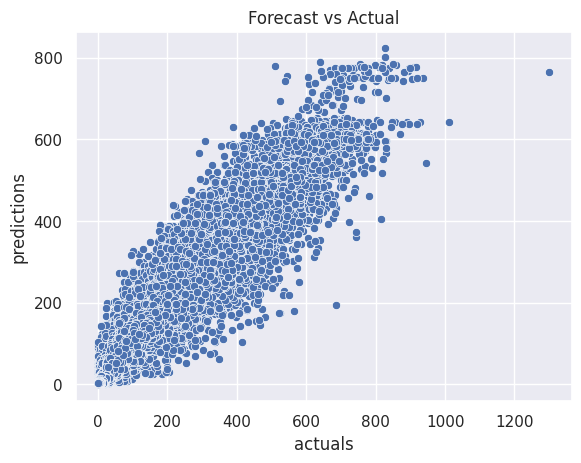

In [ ]:
sns.scatterplot(data = forecast_df.to_pandas(), x = 'actuals', y = 'predictions')
plt.title("Forecast vs Actual")
plt.show()

/tmp/ipykernel_4692/2655214154.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


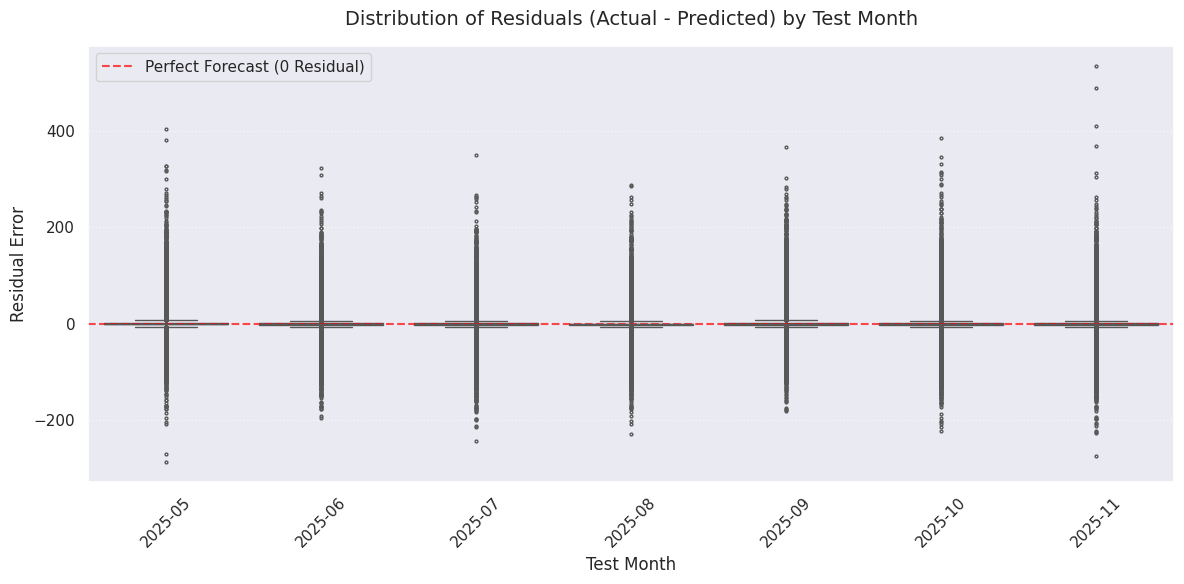

In [ ]:
plot_df = forecast_df.to_pandas()

plot_df = plot_df.sort_values("test_month")

plt.figure(figsize= (12, 6))


# Create the boxplot
sns.boxplot(
    data=plot_df,
    x="test_month",
    y="residual",
    palette="vlag",
    fliersize=2
)

# Add a dashed line at 0 (perfect prediction)
plt.axhline(0, color="red", linestyle="--", alpha=0.7, label="Perfect Forecast (0 Residual)")

plt.title("Distribution of Residuals (Actual - Predicted) by Test Month", fontsize=14, pad=15)
plt.xlabel("Test Month", fontsize=12)
plt.ylabel("Residual Error", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()